In [360]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder,MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns


In [361]:
data=pd.read_csv("/content/Loan_Default.csv")
data.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,Neg_ammortization,interest_only,lump_sum_payment,property_value,construction_type,occupancy_type,Secured_by,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,NaN,NaN,NaN,360.0,not_neg,not_int,not_lpsm,118000.0,sb,pr,home,1U,1740.0,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,NaN,NaN,NaN,360.0,not_neg,not_int,lpsm,NaN,sb,pr,home,1U,4980.0,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,4.56,0.2000,595.0,360.0,neg_amm,not_int,not_lpsm,508000.0,sb,pr,home,1U,9480.0,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,456500,4.25,0.6810,NaN,360.0,not_neg,not_int,not_lpsm,658000.0,sb,pr,home,1U,11880.0,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,696500,4.00,0.3042,0.0,360.0,not_neg,not_int,not_lpsm,758000.0,sb,pr,home,1U,10440.0,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [362]:
df=data.copy()

In [363]:
print(f"DATA info \n________________________\n{data.info()}\n__________________________")
print(f"data describetion \n___________________\n{data.describe()}\n____________________________")
print(f"data shape \n___________________\n{data.shape}\n____________________________")
print(f"data columns \n___________________\n{data.columns}\n____________________________")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   ID                         148670 non-null  int64  
 1   year                       148670 non-null  int64  
 2   loan_limit                 145326 non-null  object 
 3   Gender                     148670 non-null  object 
 4   approv_in_adv              147762 non-null  object 
 5   loan_type                  148670 non-null  object 
 6   loan_purpose               148536 non-null  object 
 7   Credit_Worthiness          148670 non-null  object 
 8   open_credit                148670 non-null  object 
 9   business_or_commercial     148670 non-null  object 
 10  loan_amount                148670 non-null  int64  
 11  rate_of_interest           112231 non-null  float64
 12  Interest_rate_spread       112031 non-null  float64
 13  Upfront_charges            10

In [364]:
def show_nulls_value(data,title):
  count_nulls=data.isnull().sum()
  count_nulls.plot(kind='bar')
  plt.title(title)
  plt.xlabel("columns name")
  plt.ylabel("count null")


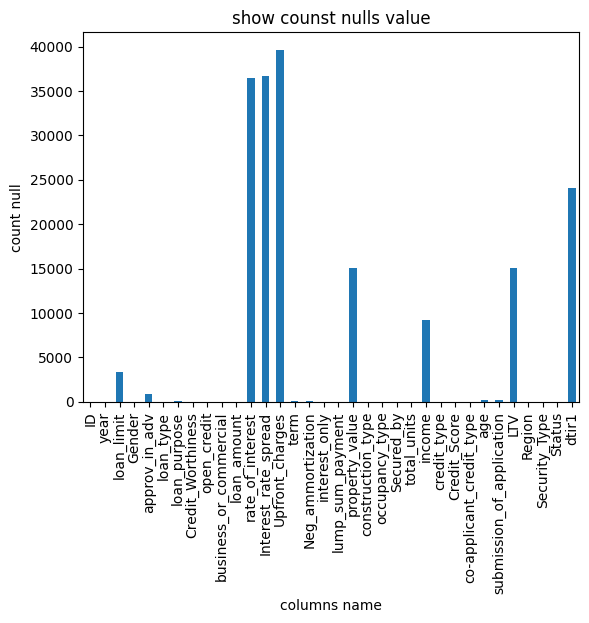

In [365]:
show_nulls_value(data,"show counst nulls value")

Text(0.5, 1.0, 'show data types')

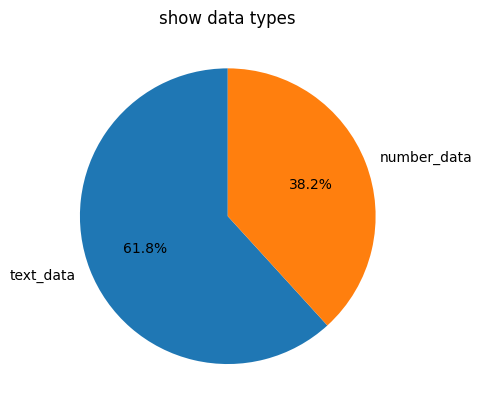

In [366]:
text_data=len(data.select_dtypes(include=['object']).columns)
number_data=len(data.select_dtypes(include=['number']).columns)
plt.pie(
    [text_data,number_data],
    labels=["text_data","number_data"],
    startangle=90,
    autopct="%1.1f%%"
)
plt.title("show data types")

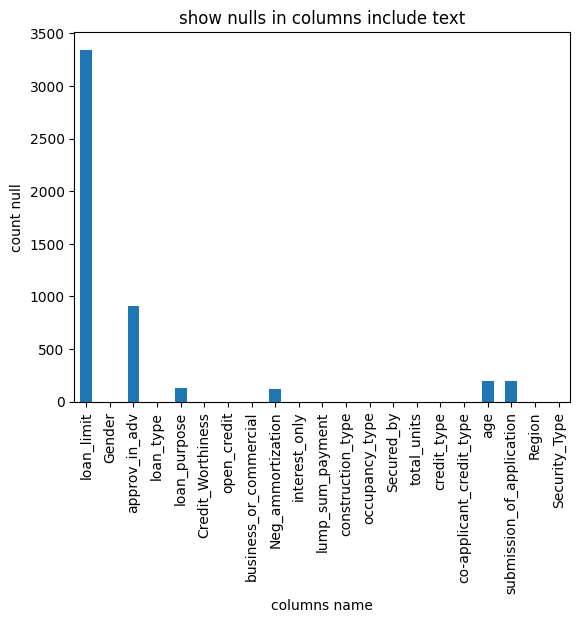

In [367]:
tdata=data.select_dtypes(include=['object'])
show_nulls_value(tdata,"show nulls in columns include text")

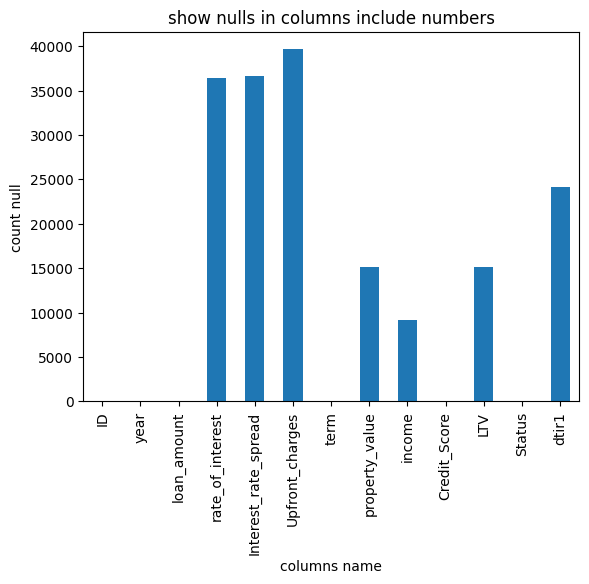

In [368]:
num_data=data.select_dtypes(include=['number'])
show_nulls_value(num_data,"show nulls in columns include numbers")

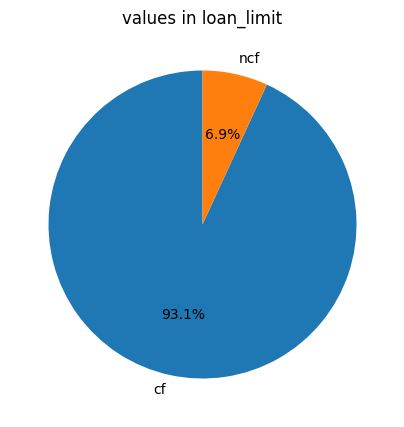

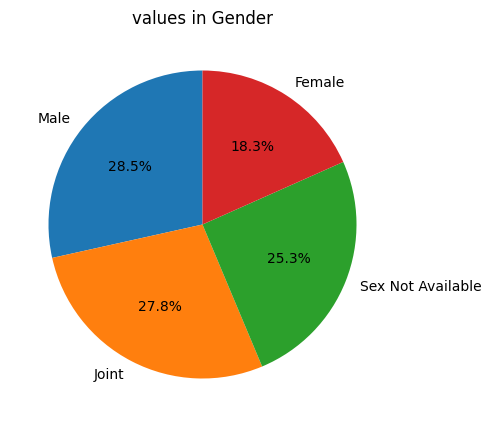

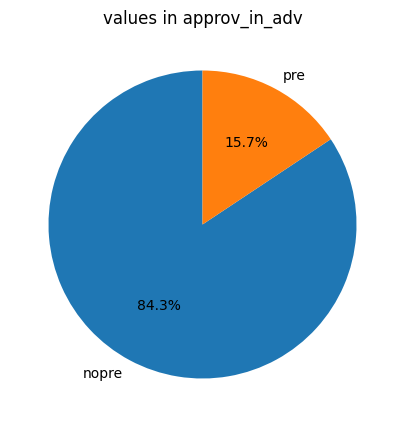

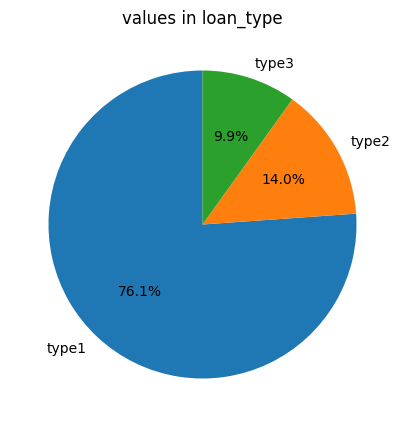

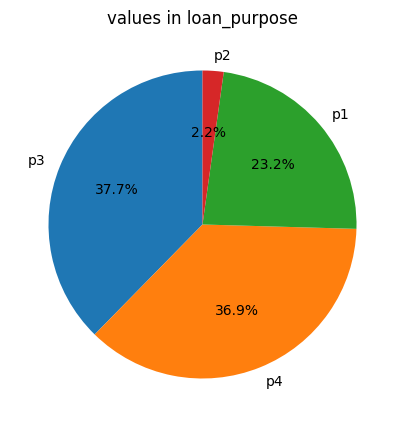

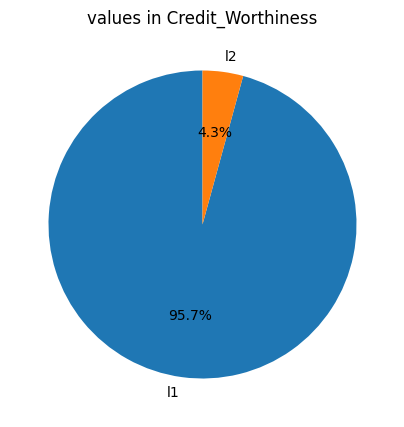

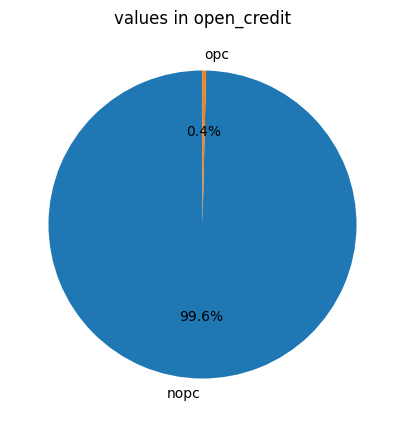

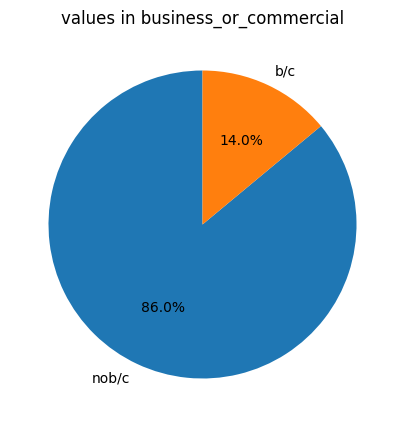

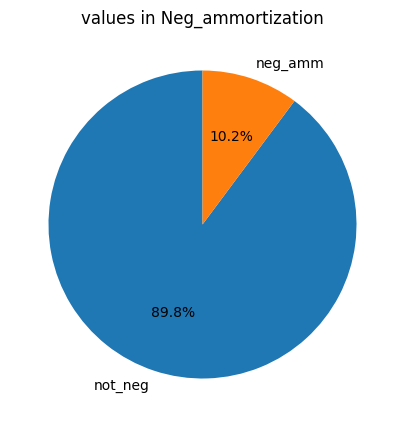

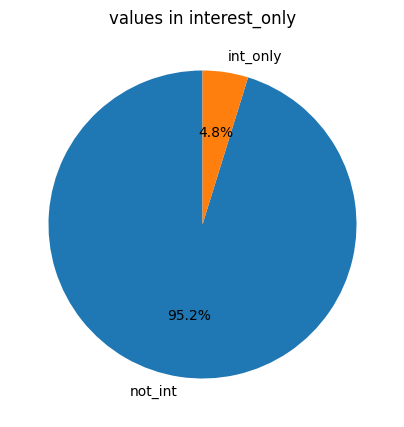

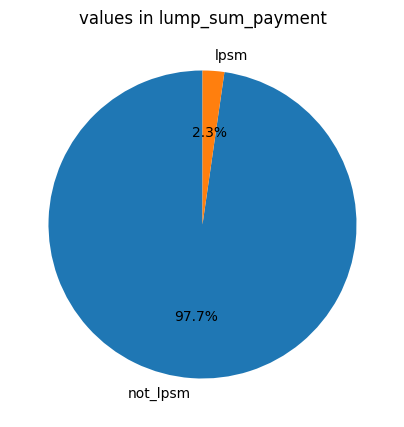

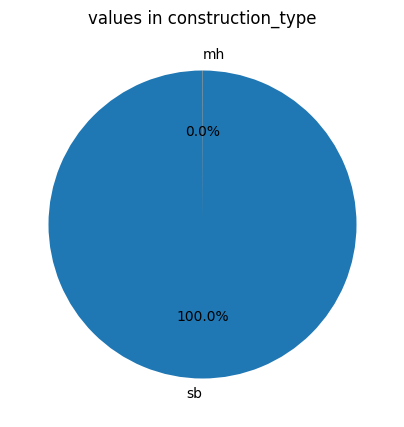

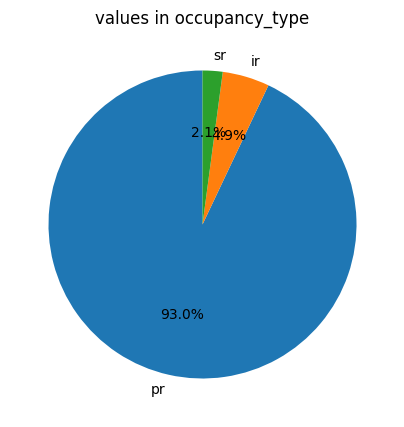

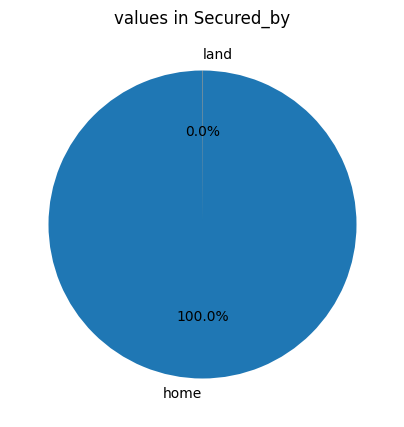

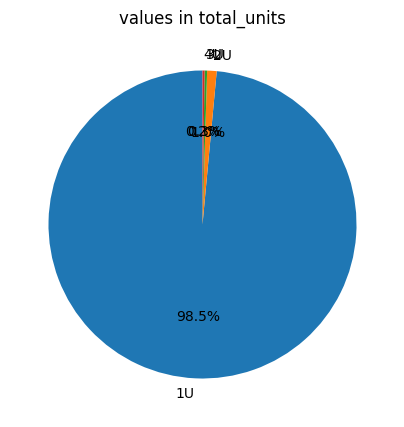

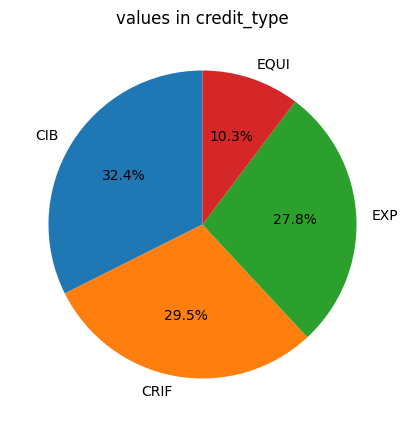

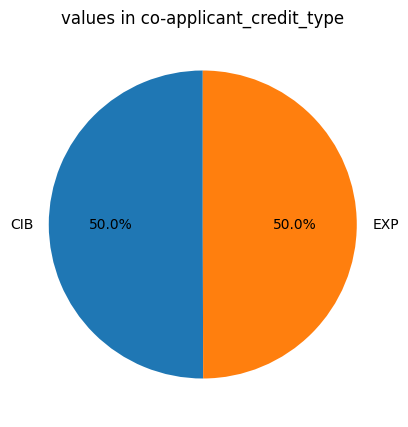

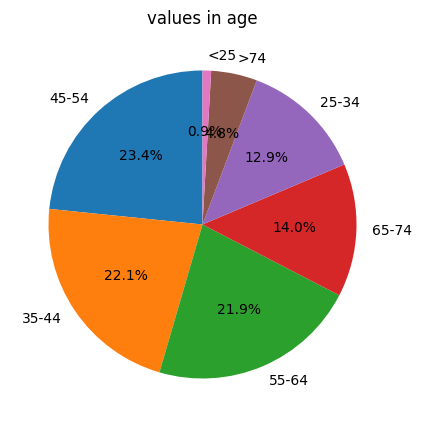

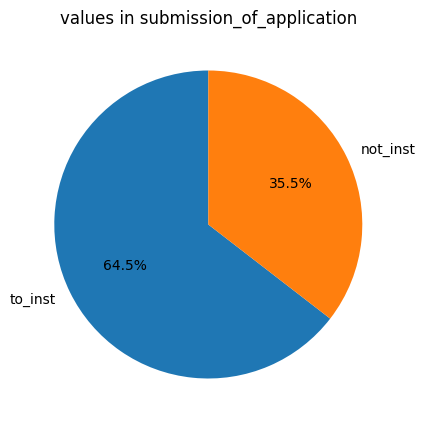

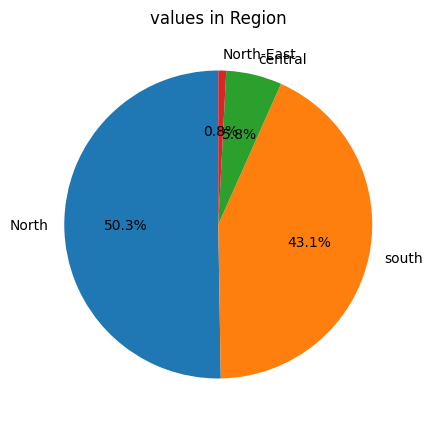

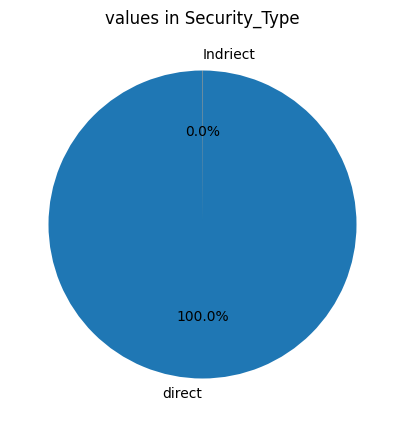

In [369]:
for col in df.select_dtypes(include=['object']).columns:
  plt.figure(figsize=(5,5))
  plt.pie(
      df[col].value_counts(),
      labels=df[col].value_counts().index,
      startangle=90,
      autopct="%1.1f%%"
  )
  plt.title(f"values in {col}")
  plt.xticks(rotation=90)
  plt.show()
  print("\n")

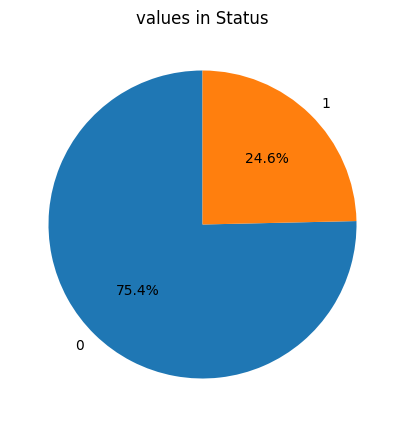

In [370]:
plt.figure(figsize=(5,5))
plt.pie(
    df['Status'].value_counts(),
    labels=df['Status'].value_counts().index,
    startangle=90,
    autopct="%1.1f%%"
)
plt.title(f"values in Status")
plt.show()
print("\n")

In [371]:
X=df.drop(['ID','Status'],axis=1)
y=df['Status']
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [372]:
for col in x_train.select_dtypes(include=['object']).columns:
  x_train[col]=x_train[col].fillna(x_train[col].mode()[0])
  x_test[col]=x_test[col].fillna(x_test[col].mode()[0])


In [373]:
for col in x_train.select_dtypes(include=['number']).columns:
  x_train[col]=x_train[col].fillna(x_train[col].mean())
  x_test[col]=x_test[col].fillna(x_test[col].mean())


In [374]:
y_train=y_train.fillna(y_train.mean())
y_test=y_test.fillna(y_test.mean())

In [375]:
print(f"x train shape : {x_train.shape}")
print(f"y train shape : {y_train.shape}")
print(f"x test shape : {x_test.shape}")
print(f"y test shape : {y_test.shape}")

x train shape : (118936, 32)
y train shape : (118936,)
x test shape : (29734, 32)
y test shape : (29734,)


In [376]:
def outlires_chart(data,title):
  plt.figure(figsize=(10, 6))
  sns.boxplot(data=data.select_dtypes(include=['number']))
  plt.xticks(rotation=90)
  plt.title(title)
  plt.xlabel("columns names")
  plt.ylabel("outliars")
  plt.show()


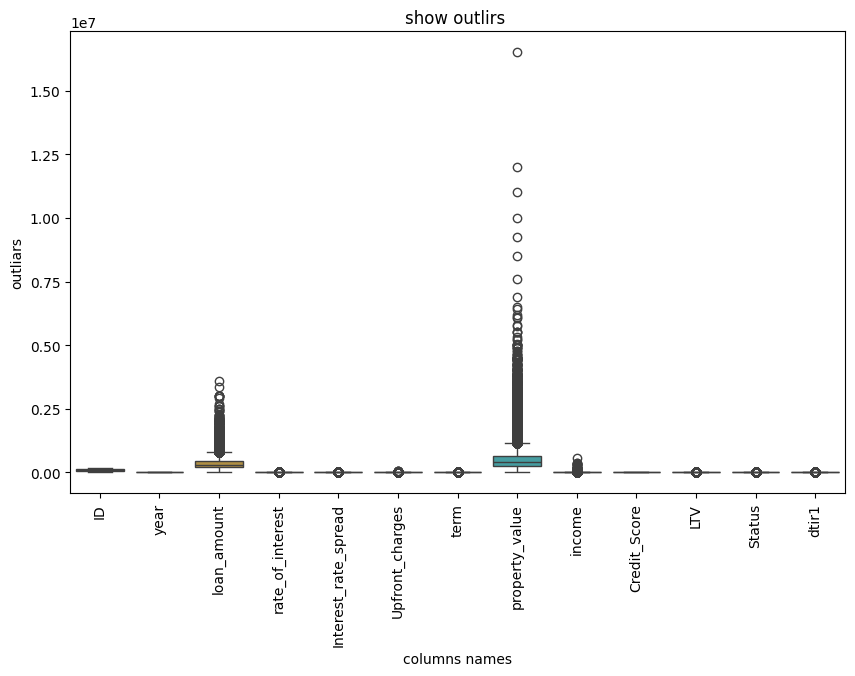

In [377]:
outlires_chart(df,"show outlirs ")

In [378]:
for col in x_train.select_dtypes(include=['number']).columns:
  q1=x_train[col].quantile(0.25)
  q3=x_train[col].quantile(0.75)
  iqr=q3-q1
  lower=q1-1.5*iqr
  upper=q3+1.5*iqr
  x_train[col]=x_train[col].clip(lower=lower,upper=upper)


  q1=x_test[col].quantile(0.25)
  q3=x_test[col].quantile(0.75)
  iqr=q3-q1
  lower=q1-1.5*iqr
  upper=q3+1.5*iqr
  x_test[col]=x_test[col].clip(lower=lower,upper=upper)

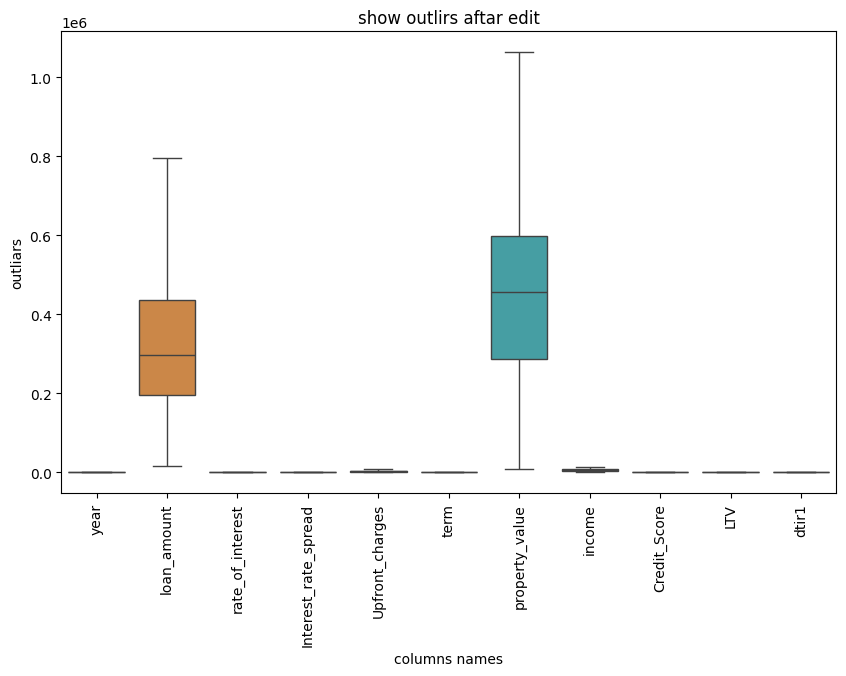

In [379]:
outlires_chart(x_train,"show outlirs aftar edit")

In [380]:
df.duplicated().sum()


np.int64(0)

In [381]:
df.columns

Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1'],
      dtype='object')

In [382]:

label_encoders = {}
for col in x_train.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    x_train[col] = le.fit_transform(x_train[col])
    x_test[col] = le.transform(x_test[col])
    label_encoders[col] = le



In [383]:
norm=MinMaxScaler()
x_train=norm.fit_transform(x_train)
x_test=norm.transform(x_test)

In [384]:
#svm
#logistc
#xgpost
#randomforst

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
logistcmodel=LogisticRegression()
svmmodel=SVC()
rfmodel=RandomForestClassifier()
xgbmodel=XGBClassifier()


In [385]:
models = [
    ('SVM', svmmodel),
    ('Logistic Regression', logistcmodel),
    ('XGBoost', xgbmodel),
    ('Random Forest', rfmodel)
]

results=[]
for name, model in models:
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Model: {name} | Accuracy: {acc:.4f}\n{'-'*30}")
    results.append({
      'Model': name,
      'Accuracy': round(acc * 100, 1)
    })
model_acc = pd.DataFrame(results)


Model: SVM | Accuracy: 0.9515
------------------------------
Model: Logistic Regression | Accuracy: 0.7853
------------------------------
Model: XGBoost | Accuracy: 0.7567
------------------------------
Model: Random Forest | Accuracy: 0.7572
------------------------------


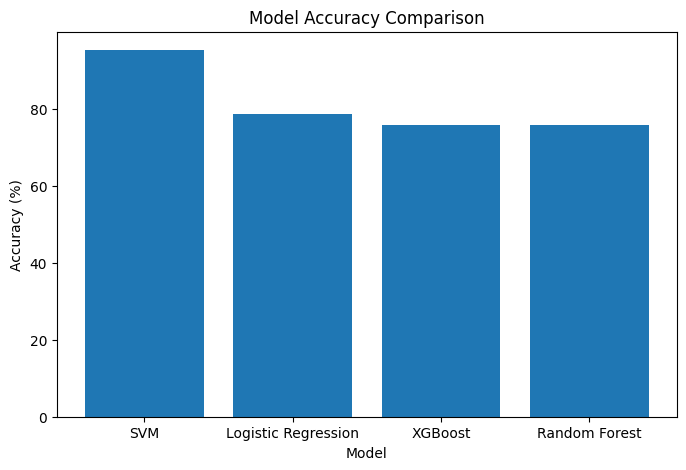

In [386]:
plt.figure(figsize=(8,5))
plt.bar(model_acc['Model'], model_acc['Accuracy'])
plt.ylabel("Accuracy (%)")
plt.xlabel("Model")
plt.title("Model Accuracy Comparison")
plt.show()


In [387]:
import joblib
joblib.dump({
    'model': svmmodel,
    'scaler': norm,
    'label_encoders': label_encoders,
}, 'default_model_full.pkl')

print("Model saved successfully!")


Model saved successfully!
